# Diagnosing barren plateaus with PyQit

A barren plateau is a flat gradient landscape. The optimizer gets no signal, so the model does not train.

This notebook:
- Diagnoses a deep model with `check_barren_plateau`.
- Runs the same check as a pre-flight with `Trainer(check_bp=True)`.

In [1]:
from sklearn.datasets import make_moons

import pyqit
from pyqit import DataModule, Trainer
from pyqit.ansatzes import SELAnsatz, SimplifiedTwoDesignAnsatz
from pyqit.core import AngleEmbedding
from pyqit.models import VQCClassifier
from pyqit.utils.diagnostic import check_barren_plateau

# The backend picks the training loop. It is not the PennyLane device.
pyqit.set_backend("pennylane")

### 1. Data

- `make_moons`, 200 samples, nonlinear.
- `normalize="minmax"` scales to [0, 1].
- `AngleEmbedding` prescaling multiplies by pi, giving [0, pi].

In [2]:
# Generate a toy dataset
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)
# AngleEmbedding prescaling multiplies by pi in setup(), so minmax here
# lands the circuit inputs in [0, pi].
dm = DataModule(
    X=X,
    y=y,
    normalize="minmax",
    batch_size=16,
    split=(0.7, 0.15, 0.15),
    seed=42,
)

### 2. Standalone diagnostic

- 8 qubits, 15 layers.
- Deep circuits at this width are likely to plateau (McClean et al.).
- `check_barren_plateau` samples gradients at random weights, before any training.

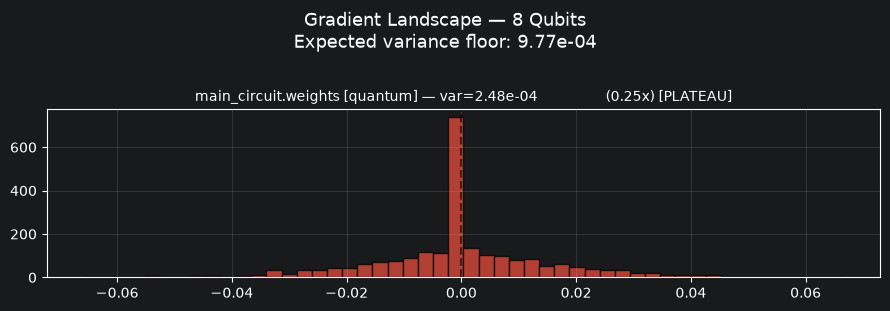


           BP Diagnostic Result : BARREN PLATEAU           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Metric / Layer              ┃    Value ┃         Status ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ Qubits                      │        8 │                │
│ Samples                     │      100 │                │
│ Circuit Executions          │      100 │                │
│ Expected Variance           │ 9.77e-04 │       Baseline │
│ Quantum Variance            │ 2.48e-04 │ BARREN PLATEAU │
├─────────────────────────────┼──────────┼────────────────┤
│ Layer: main_circuit.weights │   0.254x │      ← plateau │
└─────────────────────────────┴──────────┴────────────────┘


In [3]:
# Create an untrainable, deep VQC
bad_model = VQCClassifier(
    n_qubits=8, n_layers=15, n_classes=2, ansatz=SELAnsatz, encoder=AngleEmbedding
)
dm.setup()  # Prepare dataloaders (required for diagnostics)

# Run the standalone diagnostic tool to check for barren plateaus
result = check_barren_plateau(
    model=bad_model,
    datamodule_or_X=dm,
    num_samples=100,  # 100 random weight initializations
    plot=True,
)

print(result)

Gradient variance sits well below the baseline, and the histogram collapses to zero.

### 3. A shallow two-design at the same width

- `SimplifiedTwoDesignAnsatz` is the circuit Cerezo et al. proved trainable with a local cost at shallow depth.
- A binary `VQCClassifier` measures one wire, so the check compares against the local-cost floor `1 / 2**n_qubits`.
- Same 8 qubits, 2 layers instead of 15.

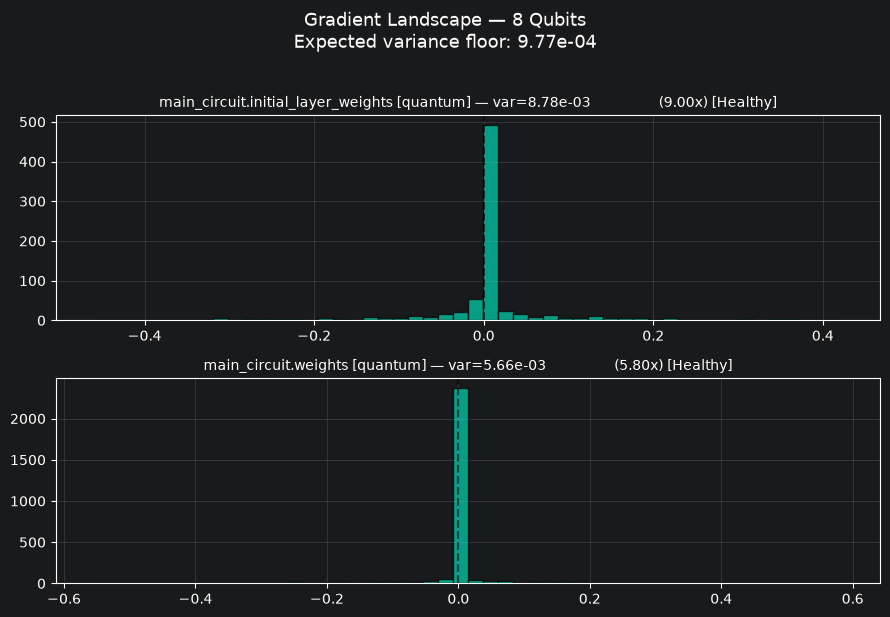


                  BP Diagnostic Result : HEALTHY                   
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric / Layer                            ┃    Value ┃   Status ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Qubits                                    │        8 │          │
│ Samples                                   │      100 │          │
│ Circuit Executions                        │      100 │          │
│ Expected Variance                         │ 9.77e-04 │ Baseline │
│ Quantum Variance                          │ 7.22e-03 │  HEALTHY │
├───────────────────────────────────────────┼──────────┼──────────┤
│ Layer: main_circuit.initial_layer_weights │   8.995x │  Healthy │
│ Layer: main_circuit.weights               │   5.798x │  Healthy │
└───────────────────────────────────────────┴──────────┴──────────┘


In [4]:
shallow_model = VQCClassifier(
    n_qubits=8,
    n_layers=2,
    n_classes=2,
    ansatz=SimplifiedTwoDesignAnsatz,
    encoder=AngleEmbedding,
)

result = check_barren_plateau(model=shallow_model, datamodule_or_X=dm, num_samples=100)
print(result)

The variance clears the floor: depth, not width, is what flattened the first circuit.

### 4. Integrated diagnostic

- 4 qubits, 3 layers.
- `Trainer(check_bp=True)` runs the check before epoch 1.
- `bp_samples` sets the number of gradient samples.

In [5]:
pyqit.set_backend("torch")  # Trying a different backend for the "good" model
dm_new = DataModule(
    X=X,
    y=y,
    normalize="minmax",
    batch_size=16,
    split=(0.7, 0.15, 0.15),
    seed=42,
)

In [6]:
# Create a healthy, shallow VQC
good_model = VQCClassifier(
    n_qubits=4, n_layers=3, n_classes=2, ansatz=SELAnsatz, encoder=AngleEmbedding
)

# Initialize the Trainer with the check enabled
trainer = Trainer(
    max_epochs=5,
    learning_rate=0.05,
    check_bp=True,  # Automated Barren Plateau check!
    bp_samples=100,
    verbose=1,  # Set to 1 to see the rich tables
)

# Fit the model
# The trainer will automatically print the diagnostic table before Epoch 1 begins.
history = trainer.fit(good_model, datamodule=dm_new)

[Trainer] Starting torch backend | 5 epochs | lr=0.05

Output()

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


           BP Diagnostic Result : BARREN PLATEAU           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Metric / Layer              ┃    Value ┃         Status ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ Qubits                      │        4 │                │
│ Samples                     │      100 │                │
│ Circuit Executions          │      100 │                │
│ Expected Variance           │ 1.56e-02 │       Baseline │
│ Quantum Variance            │ 7.25e-03 │ BARREN PLATEAU │
├─────────────────────────────┼──────────┼────────────────┤
│ Layer: main_circuit.weights │   0.464x │      ← plateau │
└─────────────────────────────┴──────────┴────────────────┘


/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


[Trainer] Training complete.